In [1]:
# Set up

In [2]:
# Setup jdk4py Java
import jdk4py
import os
os.environ["JAVA_HOME"] = str(jdk4py.JAVA_HOME)
expected = str(jdk4py.JAVA_HOME)
actual = os.getenv("JAVA_HOME")

assert actual == expected, f"\033[31mJAVA_HOME mismatch: {actual!r} != {expected!r}\033[0m"
print(f"JAVA_HOME set correctly")

# Start JVM
import os
import jpype
import jpype.imports
import orekit_jpype as orekit

if not jpype.isJVMStarted():
    orekit.initVM()

print("JVM started:", jpype.isJVMStarted())

# Import orekit data and setup
from orekit_jpype.pyhelpers import setup_orekit_curdir
setup_orekit_curdir("../data")


JAVA_HOME set correctly


JVM started: True


In [3]:
import os
import urllib.request
from java.io import File
from org.orekit.data import DataContext, DirectoryCrawler, ZipJarCrawler


data_dir = os.path.abspath(os.path.join(os.getcwd(), '..', 'data'))
os.makedirs(data_dir, exist_ok=True) 

manager = DataContext.getDefault().getDataProvidersManager()
manager.clearProviders()

orekit_zip_filename = "orekit-data.zip"
orekit_zip_path = os.path.join(data_dir, orekit_zip_filename)
orekit_url = "https://gitlab.orekit.org/orekit/orekit-data/-/archive/main/orekit-data-main.zip"

if not os.path.exists(orekit_zip_path):
    print(f"{orekit_zip_filename} downloading. Wait...")
    urllib.request.urlretrieve(orekit_url, orekit_zip_path)
    print("Orekit temel verisi başarıyla indirildi!")
else:
    print(f"{orekit_zip_filename} successfully found.")

manager.addProvider(ZipJarCrawler(File(orekit_zip_path)))

gfc_filename = "EGM2008.gfc"
gfc_path = os.path.join(data_dir, gfc_filename)

# If you receive a download error, update the link.
egm2008_url = "https://icgem.gfz.de/getmodel/gfc/c50128797a9cb62e936337c890e4425f03f0461d7329b09a8cc8561504465340/EGM2008.gfc"

# Downloaded file check
if os.path.exists(gfc_path) and os.path.getsize(gfc_path) < 1000000:
    print("Warning: EGM2008.gfc file is corrupt or missing.")
    os.remove(gfc_path)

if not os.path.exists(gfc_path):
    print(f"{gfc_filename} Downloading. It will take a while.")
    try:
        urllib.request.urlretrieve(egm2008_url, gfc_path)
        print("EGM2008 downloaded.!")
    except Exception as e:
        print(f"Download error: {e}")
else:
    print(f"{gfc_filename} successfully found.")

manager.addProvider(DirectoryCrawler(File(data_dir)))

print("done")

orekit-data.zip successfully found.
EGM2008.gfc successfully found.
done


In [4]:
from org.orekit.utils import Constants
from org.hipparchus.geometry.euclidean.threed import Vector3D
from org.orekit.time import TimeScalesFactory, AbsoluteDate
from org.orekit.frames import FramesFactory
from org.orekit.utils import PVCoordinates
from org.orekit.orbits import KeplerianOrbit, PositionAngleType
from org.orekit.propagation.analytical.tle import TLE, TLEPropagator

# Get true ISS movements for future comparison

# https://celestrak.org/NORAD/elements/gp.php?CATNR=25544
# OBJECT_NAME,OBJECT_ID,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,CLASSIFICATION_TYPE,NORAD_CAT_ID,ELEMENT_SET_NO,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT
# ISS (ZARYA),1998-067A,2026-05-31T19:22:35.605920,15.49527917,.0007243,51.6334,21.1879,119.3370,240.8343,0,U,25544,999,56921,.19064E-3,.10267E-3,0

# https://celestrak.org/NORAD/elements/gp.php?CATNR=25544&FORMAT=tle on 31.05.2026
# ISS (ZARYA)             
# 1 25544U 98067A   26151.80735655  .00010267  00000+0  19064-3 0  9992
# 2 25544  51.6334  21.1879 0007243 119.3370 240.8343 15.49527917569219

line1 = "1 25544U 98067A   26151.80735655  .00010267  00000+0  19064-3 0  9992"
line2 = "2 25544  51.6334  21.1879 0007243 119.3370 240.8343 15.49527917569219"

issTle = TLE(line1, line2)
issPropagator = TLEPropagator.selectExtrapolator(issTle)

dataAcquisitionDate = issTle.getDate()
print("Date of TLE acquisition:", dataAcquisitionDate)

trueState = issPropagator.propagate(dataAcquisitionDate)
truePV = trueState.getPVCoordinates()

# Keplerian baseline
keplerianOrbit = KeplerianOrbit(
    truePV,
    FramesFactory.getEME2000(),
    dataAcquisitionDate,
    Constants.EIGEN5C_EARTH_MU
)

print(keplerianOrbit)

Date of TLE acquisition: 2026-05-31T19:22:35.60592Z
Keplerian parameters: {a: 6802734.650079054; e: 0.0015730856790561124; i: 51.653337344422226; pa: 71.84581844133798; raan: 21.187900006876813; v: -71.84581069701204;}


In [5]:
# BULLSH*T PROPAGATION VIBE CODED I'M NOT SURE WHAT IS GOING ON HERE
# TODO rewrite and annotate

from org.orekit.propagation.numerical import NumericalPropagator
from org.hipparchus.ode.nonstiff import DormandPrince853Integrator
from org.orekit.propagation import SpacecraftState
from org.orekit.orbits import OrbitType
from org.orekit.utils import IERSConventions
from org.orekit.forces.gravity import HolmesFeatherstoneAttractionModel
from org.orekit.forces.gravity.potential import GravityFieldFactory
from org.orekit.frames import ITRFVersion
import numpy as np
import matplotlib.pyplot as plt

minStep = 0.001
maxStep = 1000.0
positionTolerance = 10.0

integrator = DormandPrince853Integrator(
    minStep,
    maxStep,
    positionTolerance,
    positionTolerance
)

propagator = NumericalPropagator(integrator)
propagator.setOrbitType(OrbitType.CARTESIAN)

propagator.setInitialState(SpacecraftState(keplerianOrbit))

degree = 20 # Latitude effect (such as J2, J3)
order = 20  # Longitude effect

provider = GravityFieldFactory.getNormalizedProvider(degree, order)

earthFrame = FramesFactory.getITRF(
    IERSConventions.IERS_2010,
    True
)

# Gravitational Force Model
egm2008_gravity = HolmesFeatherstoneAttractionModel(earthFrame, provider)

propagator.addForceModel(egm2008_gravity)

TARGET_TRAIN_ORBITS = 200
STEP_SIZE_SEC = 120 # 2 minute        

a_initial = keplerianOrbit.getA()
mu = keplerianOrbit.getMu()

T_seconds = 2 * np.pi * np.sqrt((a_initial**3) / mu)

steps_per_orbit = T_seconds / STEP_SIZE_SEC
N_base = int(np.ceil(TARGET_TRAIN_ORBITS * steps_per_orbit))

times = []
raan = []
omega = []
a_list = []
e_list = []
i_list = []
m_list = []

for k in range(N_base):
    t = k * STEP_SIZE_SEC

    state = propagator.propagate(dataAcquisitionDate.shiftedBy(t))
    orbit = state.getOrbit()

    kepler = KeplerianOrbit(orbit)

    times.append(t / 3600)  #  hours
    a_list.append(kepler.getA())
    raan.append(kepler.getRightAscensionOfAscendingNode())
    omega.append(kepler.getPerigeeArgument())
    e_list.append(kepler.getE())
    i_list.append(kepler.getI())
    m_list.append(kepler.getMeanAnomaly())

omega_array = np.array(omega)
omega_wrapped = np.arctan2(np.sin(omega_array), np.cos(omega_array))

print("done")

/home/cihat/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


done


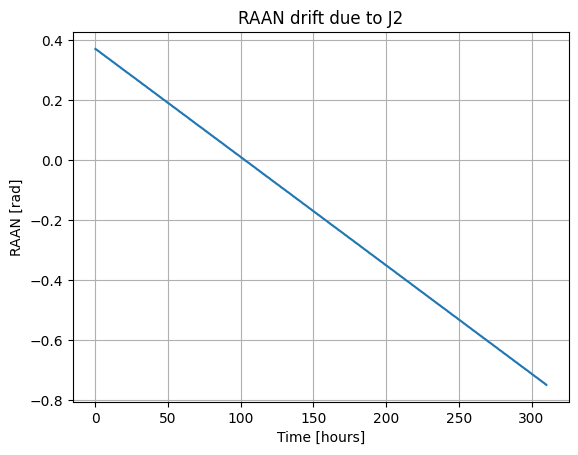

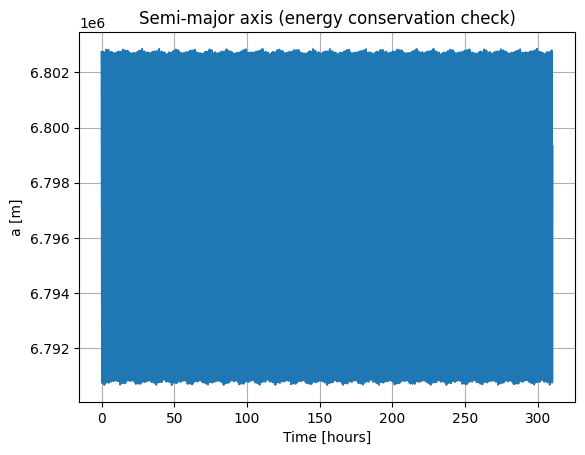

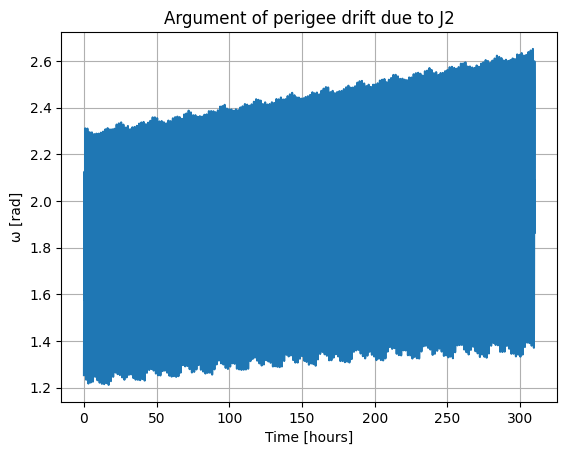

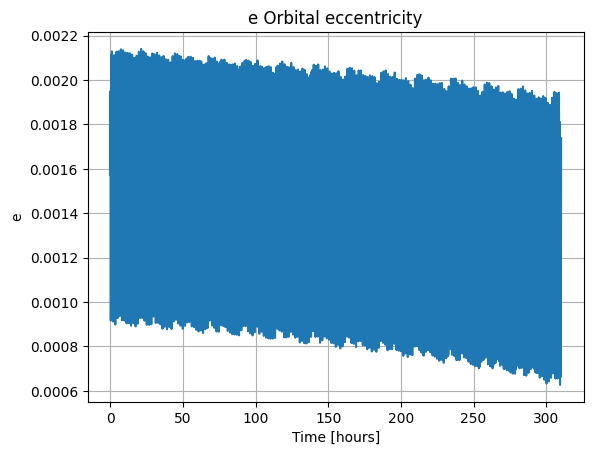

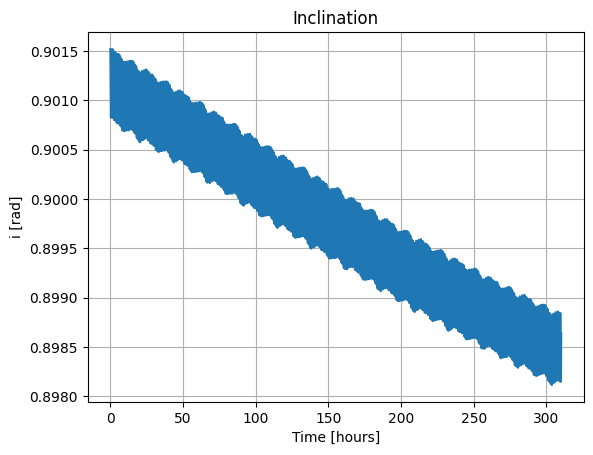

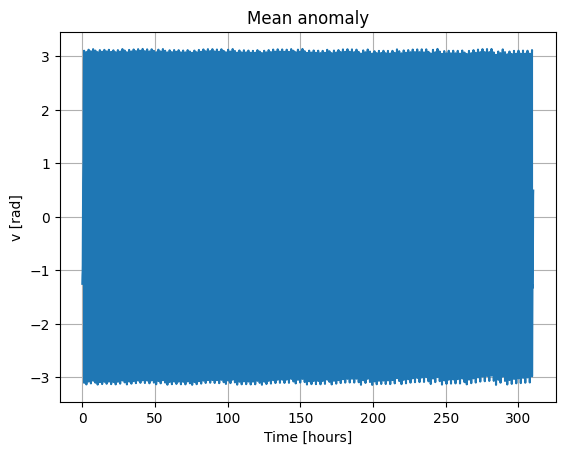

In [6]:
plt.plot(times, raan)
plt.title("RAAN drift due to J2")
plt.xlabel("Time [hours]")
plt.ylabel("RAAN [rad]")
plt.grid()
plt.show()

plt.plot(times, a_list)
plt.title("Semi-major axis (energy conservation check)")
plt.xlabel("Time [hours]")
plt.ylabel("a [m]")
plt.grid()
plt.show()

plt.plot(times, omega_wrapped)
plt.title("Argument of perigee drift due to J2")
plt.xlabel("Time [hours]")
plt.ylabel("ω [rad]")
plt.grid()
plt.show()

plt.plot(times, e_list)
plt.title("e Orbital eccentricity")
plt.xlabel("Time [hours]")
plt.ylabel("e")
plt.grid()
plt.show()

plt.plot(times, i_list)
plt.title("Inclination")
plt.xlabel("Time [hours]")
plt.ylabel("i [rad]")
plt.grid()
plt.show()

plt.plot(times, m_list)
plt.title("Mean anomaly")
plt.xlabel("Time [hours]")
plt.ylabel("v [rad]")
plt.grid()
plt.show()

In [7]:

import pandas as pd

df_all = pd.DataFrame({
    "t_hours": times, 
    "a": a_list, 
    "e": e_list, 
    "i": i_list, 
    "raan": raan, 
    "omega": omega_wrapped, 
    "m": m_list
})

df_train = df_all.iloc[:].copy()

df_train.to_csv("raw_orbit_data.csv", index=False)

print("done")

done
